# Walmart Store Sales Forecasting: N-BEATS / N-BEATSx

Second model of the deep learning track. DLinear established the honest linear floor (best val WMAE **3385.80**) and exposed its main weakness: holiday weeks (holiday MAE ~4600 vs ~2870 regular) because the model has no holiday input at all. N-BEATS attacks that from two directions: **depth** (nonlinear residual blocks instead of one linear map) and, in its N-BEATSx variant, **covariates** (future-known holiday calendar + static store attributes).

Reference points: LightGBM 1811 (tree + features + holiday blend), DLinear 3385.80 (linear univariate floor).

**MLflow experiment `NBEATS_Training`, runs in this notebook (sequential: each family carries the previous winner forward):**

| Run | What it tests |
|---|---|
| NBEATS_Cleaning | shared cleaning decisions (contract from EDA) |
| NBEATS_Data_Prep | long format, gap filling, calendar / static covariate build |
| NBEATS_Baseline | default stacks (identity+trend+seasonality), identity scaling |
| NBEATS_Scaler_standard | does DLinear's scaling win transfer to a deep model? |
| NBEATS_Stack_generic / interpretable | basis configuration: free vs constrained |
| NBEATS_Steps_2000 | is 1000 steps undertraining a 2.6M-param model? |
| NBEATSx_Calendar | future-known holiday calendar covariates |
| NBEATSx_Calendar_Static | + static store Type / Size |
| NBEATS_FINAL_MODEL | full-history retrain + pipeline artifact (raw test in, predictions out) |

Kaggle settings: **Internet ON**, competition dataset attached, GPU recommended (runs take a few minutes each here, unlike DLinear).

## 1. The N-BEATS architecture

Source: Oreshkin et al., *"N-BEATS: Neural basis expansion analysis for interpretable time series forecasting"*, ICLR 2020. A pure deep-learning forecaster (no recurrence, no attention, no hand-made features) that outperformed the winner of the M4 competition, which until then was an ensemble of statistical methods.

**The block.** The unit of N-BEATS is a block: a small MLP (fully connected layers with ReLU) that looks at the input window and emits two things through linear heads:

- a **forecast**: this block's contribution to the final prediction, and
- a **backcast**: the block's reconstruction of the part of the *input* it has explained.

**Doubly residual stacking.** Blocks are chained: block l+1 receives `input_l - backcast_l`, i.e. only what previous blocks failed to explain, and the final forecast is the **sum of all block forecasts**. This is the same idea as gradient boosting (each tree fits the residual of the previous ones), rebuilt from neural blocks, and it is why we explain it easily to the tree-track teammate.

**Basis functions: where interpretability comes from.** Each block's heads project onto a basis:

- **identity** (generic): free linear basis, the block can output any shape;
- **trend**: low-order polynomial basis, so the block can only output slow curves;
- **seasonality**: Fourier harmonics basis, so the block can only output periodic shapes.

With constrained stacks (trend + seasonality) the model's forecast decomposes into named parts, like DLinear's decomposition but *learned and nonlinear*.

**N-BEATSx** (Olivares et al., 2022) extends the block inputs with exogenous variables: future-known calendar features, static series attributes. This is exactly the lever DLinear lacked: our EDA showed each holiday behaves differently (Thanksgiving +40%, the labeled Christmas week is *below* normal because shopping happens the week before), and a model that receives per-holiday flags can react to that instead of relying on last year's window alignment.

**What we inherit from DLinear (kept identical for a fair comparison):** data prep (zero-filled weekly grid), the 91-week window constraint (`input_size=52`, `start_padding_enabled=True`), raw target (log1p was tested and rejected: WMAE is an absolute metric), evaluation protocol, MLflow structure and the pipeline export pattern.

## 2. Setup

In [1]:
!pip install -q neuralforecast mlflow dagshub

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import neuralforecast
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NBEATSx
from neuralforecast.losses.pytorch import MAE
from utilsforecast.preprocessing import fill_gaps

print('neuralforecast', neuralforecast.__version__, '| mlflow', mlflow.__version__)

neuralforecast 3.2.0 | mlflow 3.14.0


In [3]:
import dagshub
from kaggle_secrets import UserSecretsClient

dagshub.auth.add_app_token(UserSecretsClient().get_secret('DAGSHUB_TOKEN'))
dagshub.init(repo_owner='Nestor-Dzadzamia', repo_name='walmart-sales-forecasting', mlflow=True)

mlflow.set_experiment('NBEATS_Training')
exp = mlflow.get_experiment_by_name('NBEATS_Training')
assert exp is not None and str(exp.experiment_id) != '0', 'runs would land in the Default experiment'
print('tracking uri:', mlflow.get_tracking_uri())
print('experiment:', exp.name, '| id:', exp.experiment_id)

The added token already exists in the token cache, skipping


Accessing as Nestor-Dzadzamia

Initialized MLflow to track repo "Nestor-Dzadzamia/walmart-sales-forecasting"

Repository Nestor-Dzadzamia/walmart-sales-forecasting initialized!

tracking uri: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow
experiment: NBEATS_Training | id: 2


## 3. Shared logic between team members (copied logic/code from the EDA notebook)

In [4]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])
    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]

def preprocess(df):
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    return out

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

In [5]:
path = '/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(path + 'train.csv.zip')
test = pd.read_csv(path + 'test.csv.zip')
features = pd.read_csv(path + 'features.csv.zip')
stores = pd.read_csv(path + 'stores.csv')

df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)
print('train merged:', df.shape, '| test merged:', df_test.shape)

train merged: (421570, 16) | test merged: (115064, 15)


In [6]:
with mlflow.start_run(run_name='NBEATS_Cleaning'):
    mlflow.log_param('markdown_fill', '0')
    mlflow.log_param('cpi_unemployment_fill', 'ffill_per_store')
    mlflow.log_metric('markdown_nan_before', int(df[MD_COLS].isna().sum().sum()))

    df_clean = preprocess(df)

    mlflow.log_metric('markdown_nan_after', int(df_clean[MD_COLS].isna().sum().sum()))
    mlflow.log_metric('train_rows', len(df_clean))

print(df_clean.shape)

🏃 View run NBEATS_Cleaning at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/3a13a51956544937ba258e3202ed71c1
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
(421570, 16)


In [7]:
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)
VALIDATION_END = VALIDATION_START + pd.Timedelta(weeks=39)

def temporal_split(df):
    tr = df[df["Date"] < VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va

tr, va = temporal_split(df_clean)
print('train:', tr['Date'].max(), tr.shape)
print('val:  ', va['Date'].min(), '->', va['Date'].max(), va.shape)

train: 2011-10-28 00:00:00 (267184, 16)
val:   2011-11-04 00:00:00 -> 2012-07-27 00:00:00 (115856, 16)


## 4. Data preparation: weekly grid + covariates

Same long-format grid as DLinear (missing Fridays inserted, `y=0`: a missing week means no sales were recorded). New in this notebook, for N-BEATSx:

- **Future-known calendar covariates**, computable for any date, so they exist for the forecast horizon too: per-holiday week flags (EDA showed the four holidays are NOT equal: Thanksgiving spikes hard, the labeled Christmas week is below normal), a pre-Christmas-week flag (where the actual shopping peak lives), weeks-until-Christmas distance, and smooth week-of-year encoding (sin/cos).
- **Static covariates** per series: store Type (one-hot) and Size (scaled), the two store attributes EDA found meaningful.
- **Deliberately excluded**: markdowns. They are known only historically (would need a separate hist-exog path), are structurally missing before Nov 2011, and EDA measured their lift at ~1.9%. Low expected value for real plumbing cost.

In [8]:
HORIZON = 39
FREQ = 'W-FRI'

HOLIDAY_WEEKS = {
    'is_superbowl_week': ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'],
    'is_laborday_week': ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'],
    'is_thanksgiving_week': ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'],
    'is_christmas_week': ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'],
}
CHRISTMAS_FRIDAYS = pd.to_datetime(HOLIDAY_WEEKS['is_christmas_week'])

def add_calendar_exog(frame):
    out = frame.copy()
    ds = pd.to_datetime(out['ds'])
    for col, dates in HOLIDAY_WEEKS.items():
        out[col] = ds.isin(pd.to_datetime(dates)).astype(float)
    out['is_pre_christmas_week'] = ds.isin(CHRISTMAS_FRIDAYS - pd.Timedelta(weeks=1)).astype(float)
    idx = np.clip(np.searchsorted(CHRISTMAS_FRIDAYS.values, ds.values), 0, len(CHRISTMAS_FRIDAYS) - 1)
    nxt = CHRISTMAS_FRIDAYS.values[idx]
    out['weeks_to_christmas'] = np.clip((nxt - ds.values).astype('timedelta64[D]').astype(float) / 7.0, 0, None) / 52.0
    woy = ds.dt.isocalendar().week.astype(float)
    out['woy_sin'] = np.sin(2 * np.pi * woy / 52.0)
    out['woy_cos'] = np.cos(2 * np.pi * woy / 52.0)
    return out

FUTR_COLS = ['is_superbowl_week', 'is_laborday_week', 'is_thanksgiving_week',
             'is_christmas_week', 'is_pre_christmas_week', 'weeks_to_christmas',
             'woy_sin', 'woy_cos']

def to_long(frame):
    out = frame[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
    out['unique_id'] = out['Store'].astype(str) + '_' + out['Dept'].astype(str)
    out = out.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    return out[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)

tr_long = fill_gaps(to_long(tr), freq=FREQ, start='per_serie', end='global')
n_gap_rows = int(tr_long['y'].isna().sum())
tr_long['y'] = tr_long['y'].fillna(0.0)
tr_long_exog = add_calendar_exog(tr_long)

series_len = tr_long.groupby('unique_id').size()
print('series:', tr_long['unique_id'].nunique(), '| rows:', len(tr_long), f'({n_gap_rows} gap rows zero-filled)')
print('covariate columns:', FUTR_COLS)

series: 3254 | rows: 289864 (22680 gap rows zero-filled)
covariate columns: ['is_superbowl_week', 'is_laborday_week', 'is_thanksgiving_week', 'is_christmas_week', 'is_pre_christmas_week', 'weeks_to_christmas', 'woy_sin', 'woy_cos']


In [9]:
stat = df_clean[['Store', 'Dept', 'Type', 'Size']].drop_duplicates(['Store', 'Dept']).copy()
stat['unique_id'] = stat['Store'].astype(str) + '_' + stat['Dept'].astype(str)
static_df = pd.DataFrame({
    'unique_id': stat['unique_id'].values,
    'type_A': (stat['Type'] == 'A').astype(float).values,
    'type_B': (stat['Type'] == 'B').astype(float).values,
    'size_scaled': (stat['Size'] / stat['Size'].max()).values,
})
STATIC_COLS = ['type_A', 'type_B', 'size_scaled']

def make_futr_df(last_ds, ids):
    future_ds = pd.date_range(last_ds + pd.Timedelta(weeks=1), periods=HORIZON, freq=FREQ)
    base = pd.DataFrame({'unique_id': np.repeat(ids, HORIZON),
                         'ds': np.tile(future_ds, len(ids))})
    return add_calendar_exog(base)

va_eval = va[['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']].copy()
va_eval['unique_id'] = va_eval['Store'].astype(str) + '_' + va_eval['Dept'].astype(str)

with mlflow.start_run(run_name='NBEATS_Data_Prep'):
    mlflow.log_param('format', 'long (unique_id, ds, y) + calendar exog')
    mlflow.log_param('futr_exog', ', '.join(FUTR_COLS))
    mlflow.log_param('static_exog', ', '.join(STATIC_COLS))
    mlflow.log_param('excluded', 'markdowns (hist-only, weak effect ~1.9%)')
    mlflow.log_metric('n_series_train', tr_long['unique_id'].nunique())
    mlflow.log_metric('gap_rows_zero_filled', n_gap_rows)

print('static_df:', static_df.shape, '| validation rows:', len(va_eval))

🏃 View run NBEATS_Data_Prep at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/73b3355c013d46ca87cd0084000e2520
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
static_df: (3331, 4) | validation rows: 115856


## 5. Evaluation protocol and the run helper

Identical to DLinear: fit on pre-validation history, forecast 39 weeks, left-join onto actual validation rows (uncovered series score 0, coverage logged), shared WMAE with real holiday flags. One helper runs any configuration (NBEATS or NBEATSx) and logs one MLflow run, so the DagsHub table stays directly comparable across the whole DL track.

In [10]:
STACKS = {
    'default': ['identity', 'trend', 'seasonality'],
    'generic': ['identity', 'identity', 'identity'],
    'interpretable': ['trend', 'seasonality'],
}

def train_and_eval(run_name, model_name='NBEATS', stack_label='default', input_size=52,
                   scaler_type='identity', max_steps=1000, learning_rate=1e-3,
                   batch_size=32, seed=42, use_futr=False, use_static=False):
    stack_types = STACKS[stack_label]
    kwargs = dict(h=HORIZON, input_size=input_size,
                  stack_types=stack_types,
                  n_blocks=[3] * len(stack_types),
                  mlp_units=[[512, 512]] * len(stack_types),
                  loss=MAE(), scaler_type=scaler_type, learning_rate=learning_rate,
                  max_steps=max_steps, batch_size=batch_size,
                  start_padding_enabled=True, random_seed=seed, logger=False, devices=1)

    if model_name == 'NBEATSx':
        if use_futr:
            kwargs['futr_exog_list'] = FUTR_COLS
        if use_static:
            kwargs['stat_exog_list'] = STATIC_COLS
        model = NBEATSx(**kwargs)
        fit_df = tr_long_exog
    else:
        model = NBEATS(**kwargs)
        fit_df = tr_long

    nf = NeuralForecast(models=[model], freq=FREQ)
    nf.fit(df=fit_df, static_df=static_df if use_static else None)

    if use_futr:
        futr = make_futr_df(tr_long['ds'].max(), fit_df['unique_id'].unique())
        preds = nf.predict(futr_df=futr)
    else:
        preds = nf.predict()
    if 'unique_id' not in preds.columns:
        preds = preds.reset_index()
    pred_col = [c for c in preds.columns if c not in ('unique_id', 'ds')][0]
    preds = preds.rename(columns={pred_col: 'y_hat'})

    merged = va_eval.merge(preds[['unique_id', 'ds', 'y_hat']],
                           left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
    coverage = float(merged['y_hat'].notna().mean())
    merged['y_hat'] = merged['y_hat'].fillna(0).clip(lower=0)

    score = float(wmae(merged['Weekly_Sales'], merged['y_hat'], merged['IsHoliday']))
    err = np.abs(merged['Weekly_Sales'] - merged['y_hat'])
    hol = merged['IsHoliday'].astype(bool)
    metrics = {'val_wmae': score,
               'val_mae': float(err.mean()),
               'val_mae_holiday': float(err[hol].mean()),
               'val_mae_regular': float(err[~hol].mean()),
               'pred_coverage': coverage}
    params = {'model': model_name, 'stack_label': stack_label, 'input_size': input_size,
              'scaler_type': scaler_type, 'max_steps': max_steps, 'learning_rate': learning_rate,
              'batch_size': batch_size, 'seed': seed, 'use_futr': use_futr,
              'use_static': use_static, 'horizon': HORIZON, 'loss': 'MAE'}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        for k, v in metrics.items():
            mlflow.log_metric(k, v)

    wmae_str = f'{score:,.2f}'
    print(f'{run_name}: WMAE={wmae_str} | MAE={metrics["val_mae"]:,.2f} | '
          f'holiday MAE={metrics["val_mae_holiday"]:,.2f} | coverage={coverage:.1%}')
    return {'run': run_name, **params, **metrics}, nf, merged

results = []
merged_map = {}

## 6. Baseline

Default N-BEATS: mixed stacks (identity + trend + seasonality), 3 blocks each, width 512 (~2.6M parameters vs DLinear's 4k), identity scaling, raw target, input 52. The first question this answers: does depth alone beat the linear model?

In [11]:
res, _, m = train_and_eval('NBEATS_Baseline')
results.append(res); merged_map[res['run']] = m
print('DLinear reference: 3385.80')

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.7 M  | train
--------------------------------------------------------------
7.7 M     Trainable params
21.6 K    Non-trainable params
7.7 M     Total params
30.963    Total estimated model params size (MB)
88        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_Baseline at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/ba6ccbb5642e40a3a1af3ed71c7291e4
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
NBEATS_Baseline: WMAE=2,390.50 | MAE=2,106.85 | holiday MAE=3,300.80 | coverage=99.6%
DLinear reference: 3385.80


## 7. Experiment: per-window scaling (transfer from DLinear)

Standard per-window scaling was DLinear's single biggest win (3460 to 3386). The hypothesis transfers: series spanning orders of magnitude are hard for shared weights regardless of depth. Whichever scaler wins here is carried into every following run.

In [12]:
res, _, m = train_and_eval('NBEATS_Scaler_standard', scaler_type='standard')
results.append(res); merged_map[res['run']] = m

fam = [r for r in results if r['run'] in ('NBEATS_Baseline', 'NBEATS_Scaler_standard')]
best_scaler = min(fam, key=lambda r: r['val_wmae'])['scaler_type']
print('carrying forward scaler_type =', best_scaler)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.7 M  | train
--------------------------------------------------------------
7.7 M     Trainable params
21.6 K    Non-trainable params
7.7 M     Total params
30.963    Total estimated model params size (MB)
88        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_Scaler_standard at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/b889b27c78864487bb63a8fa19967b26
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
NBEATS_Scaler_standard: WMAE=2,667.78 | MAE=2,241.92 | holiday MAE=4,034.49 | coverage=99.6%
carrying forward scaler_type = identity


## 8. Experiment: stack configuration

Three basis configurations against each other (with the winning scaler):

- **default**: identity + trend + seasonality (the baseline already tested this),
- **generic**: identity only, maximum freedom, the paper's strongest accuracy configuration,
- **interpretable**: trend + seasonality only, constrained bases, decomposable output.

The paper found generic slightly more accurate and interpretable close behind; our data has unusually clean seasonality, so the constrained version has a real chance here.

In [13]:
for label in ['generic', 'interpretable']:
    res, _, m = train_and_eval(f'NBEATS_Stack_{label}', stack_label=label, scaler_type=best_scaler)
    results.append(res); merged_map[res['run']] = m

fam = [r for r in results if r['run'].startswith('NBEATS_Stack')
       or (r['run'] in ('NBEATS_Baseline', 'NBEATS_Scaler_standard') and r['scaler_type'] == best_scaler)]
best_stack = min(fam, key=lambda r: r['val_wmae'])['stack_label']
print('carrying forward stack_label =', best_stack)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.8 M  | train
--------------------------------------------------------------
7.8 M     Trainable params
0         Non-trainable params
7.8 M     Total params
31.024    Total estimated model params size (MB)
88        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_Stack_interpretable at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/458fcba524464ff299835382f447a846
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
NBEATS_Stack_interpretable: WMAE=2,342.47 | MAE=2,093.53 | holiday MAE=3,141.40 | coverage=99.6%
carrying forward stack_label = interpretable


## 9. Experiment: training length

DLinear converged in 1000 steps because it is linear. A 2.6M-parameter MLP stack may still be improving at that point. One run at 2000 steps with the winners so far; if it does not help, 1000 is confirmed as converged.

In [14]:
res, _, m = train_and_eval('NBEATS_Steps_2000', stack_label=best_stack,
                           scaler_type=best_scaler, max_steps=2000)
results.append(res); merged_map[res['run']] = m

fam = [r for r in results if r['stack_label'] == best_stack and r['scaler_type'] == best_scaler
       and not r['use_futr'] and not r['use_static']]
best_steps = min(fam, key=lambda r: r['val_wmae'])['max_steps']
print('carrying forward max_steps =', best_steps)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.6 M  | train
--------------------------------------------------------------
3.6 M     Trainable params
21.6 K    Non-trainable params
3.6 M     Total params
14.318    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_Steps_2000 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/ec948020dd9842d899898237e560adf4
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
NBEATS_Steps_2000: WMAE=2,401.32 | MAE=2,137.14 | holiday MAE=3,249.16 | coverage=99.6%
carrying forward max_steps = 1000


## 10. The headline experiment: N-BEATSx with covariates

DLinear's documented weakness: holiday MAE ~4600 vs ~2870 regular, because it cannot see holidays. N-BEATSx receives the holiday calendar (future-known flags incl. the pre-Christmas shopping week, weeks-to-Christmas distance, smooth week-of-year) and optionally static store identity (Type, Size).

Note: N-BEATSx runs use the default stack configuration (the exogenous inputs enter the blocks; custom basis constraints combined with exog is an API edge we deliberately avoid). Scaler and steps winners carry over.

Watch `val_mae_holiday` specifically: if covariates work, that number should drop much more than the regular-week error.

In [15]:
res, _, m = train_and_eval('NBEATSx_Calendar', model_name='NBEATSx',
                           scaler_type=best_scaler, max_steps=best_steps, use_futr=True)
results.append(res); merged_map[res['run']] = m

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 11.1 M | train
--------------------------------------------------------------
11.1 M    Trainable params
21.6 K    Non-trainable params
11.1 M    Total params
44.381    Total estimated model params size (MB)
88        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATSx_Calendar at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/2f78c332698e435da7aec3ce3e6eb669
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
NBEATSx_Calendar: WMAE=2,388.77 | MAE=2,097.20 | holiday MAE=3,324.52 | coverage=99.6%


In [16]:
res, _, m = train_and_eval('NBEATSx_Calendar_Static', model_name='NBEATSx',
                           scaler_type=best_scaler, max_steps=best_steps,
                           use_futr=True, use_static=True)
results.append(res); merged_map[res['run']] = m

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 11.1 M | train
--------------------------------------------------------------
11.1 M    Trainable params
21.6 K    Non-trainable params
11.1 M    Total params
44.437    Total estimated model params size (MB)
88        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATSx_Calendar_Static at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/f0a5807bece24afb8576d46c1548f7a9
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
NBEATSx_Calendar_Static: WMAE=2,444.24 | MAE=2,147.30 | holiday MAE=3,397.21 | coverage=99.6%


## 11. Results

In [17]:
results_df = pd.DataFrame(results).sort_values('val_wmae').reset_index(drop=True)
cols = ['run', 'model', 'stack_label', 'scaler_type', 'max_steps', 'use_futr', 'use_static',
        'val_wmae', 'val_mae', 'val_mae_holiday', 'val_mae_regular', 'pred_coverage']
display(results_df[cols])
print('references: DLinear 3385.80 | LightGBM 1811')

,run,model,stack_label,scaler_type,max_steps,use_futr,use_static,val_wmae,val_mae,val_mae_holiday,val_mae_regular,pred_coverage
0,NBEATS_Stack_interpretable,NBEATS,interpretable,identity,1000,False,False,2342.471503,2093.529666,3141.402402,2005.006190,0.996435
1,NBEATSx_Calendar,NBEATSx,default,identity,1000,True,False,2388.773119,2097.199650,3324.522034,1993.516408,0.996435
2,NBEATS_Baseline,NBEATS,default,identity,1000,False,False,2390.495545,2106.849136,3300.804089,2005.984747,0.996435
3,NBEATS_Steps_2000,NBEATS,interpretable,identity,2000,False,False,2401.322387,2137.141468,3249.160185,2043.198990,0.996435
4,NBEATSx_Calendar_Static,NBEATSx,default,identity,1000,True,True,2444.242012,2147.303823,3397.207964,2041.712891,0.996435
5,NBEATS_Stack_generic,NBEATS,generic,identity,1000,False,False,2446.680047,2134.059864,3449.974336,2022.892431,0.996435
6,NBEATS_Scaler_standard,NBEATS,default,standard,1000,False,False,2667.777235,2241.916983,4034.493729,2090.481490,0.996435


references: DLinear 3385.80 | LightGBM 1811


## 12. Error analysis of the best run

Same two views as DLinear for direct comparison: WMAE per validation week (holiday weeks in red) and example series. The key question: did the holiday spikes that dominated DLinear's error profile shrink?

best run: NBEATS_Stack_interpretable


/tmp/ipykernel_149/1834974901.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_week = best.groupby('Date').apply(lambda g: wmae(g['Weekly_Sales'], g['y_hat'], g['IsHoliday']))


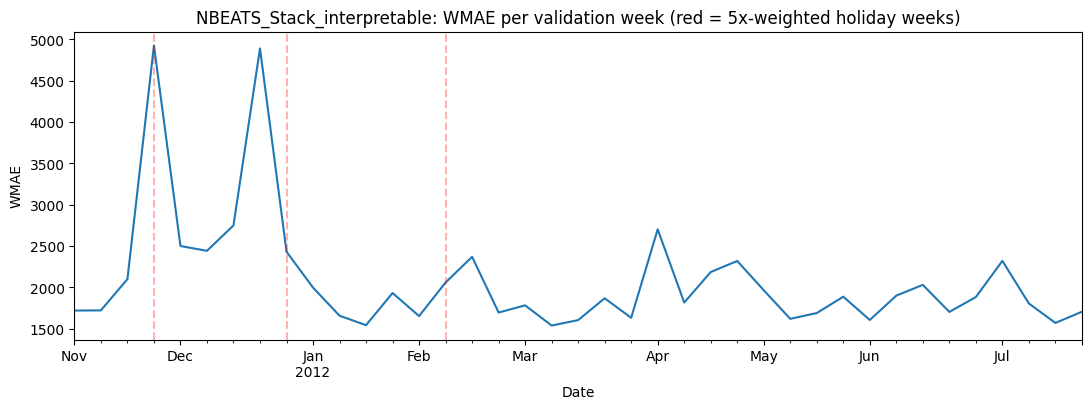

In [18]:
best_run_name = results_df.iloc[0]['run']
best = merged_map[best_run_name]
print('best run:', best_run_name)

by_week = best.groupby('Date').apply(lambda g: wmae(g['Weekly_Sales'], g['y_hat'], g['IsHoliday']))
hol_weeks = best.loc[best['IsHoliday'].astype(bool), 'Date'].unique()

fig, ax = plt.subplots(figsize=(13, 4))
by_week.plot(ax=ax)
for d in hol_weeks:
    ax.axvline(d, color='red', alpha=0.3, linestyle='--')
ax.set_title(f'{best_run_name}: WMAE per validation week (red = 5x-weighted holiday weeks)')
ax.set_ylabel('WMAE')
plt.show()

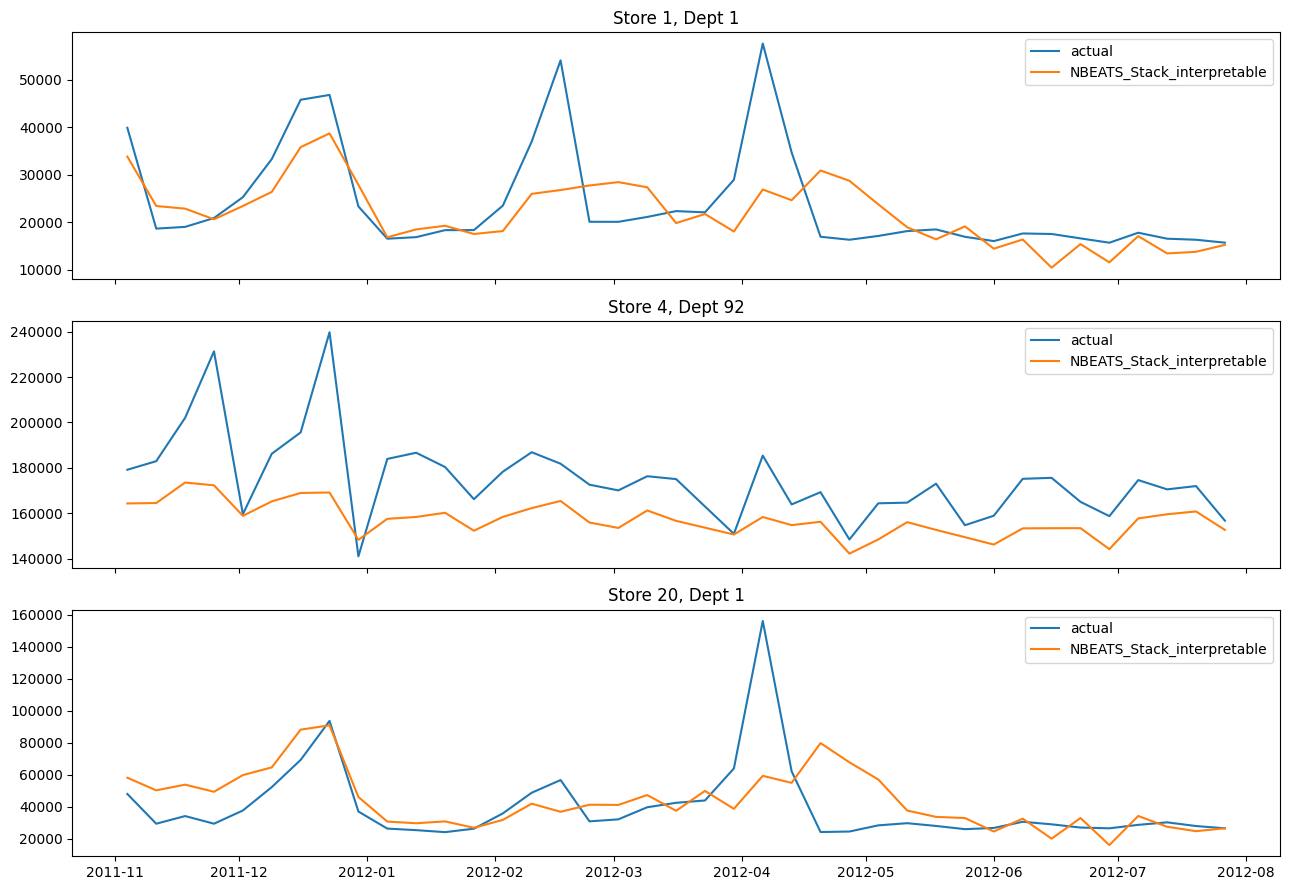

In [19]:
examples = [(1, 1), (4, 92), (20, 1)]
fig, axes = plt.subplots(len(examples), 1, figsize=(13, 9), sharex=True)
for ax, (s, d) in zip(axes, examples):
    sub = best[(best['Store'] == s) & (best['Dept'] == d)].sort_values('Date')
    ax.plot(sub['Date'], sub['Weekly_Sales'], label='actual')
    ax.plot(sub['Date'], sub['y_hat'], label=best_run_name)
    ax.set_title(f'Store {s}, Dept {d}')
    ax.legend()
plt.tight_layout(); plt.show()

In [20]:
dl_holiday_mae = 4604.76
nb_holiday_mae = float(results_df.iloc[0]['val_mae_holiday'])
nb_regular_mae = float(results_df.iloc[0]['val_mae_regular'])
print(f'holiday MAE: DLinear best {dl_holiday_mae:,.0f} -> N-BEATS best {nb_holiday_mae:,.0f} '
      f'({(nb_holiday_mae / dl_holiday_mae - 1) * 100:+.1f}%)')
print(f'regular MAE: N-BEATS best {nb_regular_mae:,.0f} (DLinear best was ~2870)')

holiday MAE: DLinear best 4,605 -> N-BEATS best 3,141 (-31.8%)
regular MAE: N-BEATS best 2,005 (DLinear best was ~2870)


## 13. Final model: retrain on full history

Per shared decision #6: the winning configuration retrained on all 143 weeks, then the 39 test weeks are forecast. Cold-start rows get the shared fallback, predictions clipped at 0, submission written.

In [21]:
best_row = results_df.iloc[0]
best_cfg = {'model_name': str(best_row['model']), 'stack_label': str(best_row['stack_label']),
            'input_size': int(best_row['input_size']), 'scaler_type': str(best_row['scaler_type']),
            'max_steps': int(best_row['max_steps']), 'use_futr': bool(best_row['use_futr']),
            'use_static': bool(best_row['use_static'])}
best_val_wmae = float(best_row['val_wmae'])
print('final config:', best_cfg, '| validated WMAE:', round(best_val_wmae, 2))

full_long = fill_gaps(to_long(df_clean), freq=FREQ, start='per_serie', end='global')
full_long['y'] = full_long['y'].fillna(0.0)
full_long_exog = add_calendar_exog(full_long)

stack_types = STACKS[best_cfg['stack_label']]
kwargs = dict(h=HORIZON, input_size=best_cfg['input_size'],
              stack_types=stack_types, n_blocks=[3] * len(stack_types),
              mlp_units=[[512, 512]] * len(stack_types),
              loss=MAE(), scaler_type=best_cfg['scaler_type'], learning_rate=1e-3,
              max_steps=best_cfg['max_steps'], batch_size=32,
              start_padding_enabled=True, random_seed=42, logger=False, devices=1)

if best_cfg['model_name'] == 'NBEATSx':
    if best_cfg['use_futr']:
        kwargs['futr_exog_list'] = FUTR_COLS
    if best_cfg['use_static']:
        kwargs['stat_exog_list'] = STATIC_COLS
    final_model = NBEATSx(**kwargs)
    fit_full = full_long_exog
else:
    final_model = NBEATS(**kwargs)
    fit_full = full_long

nf_final = NeuralForecast(models=[final_model], freq=FREQ)
nf_final.fit(df=fit_full, static_df=static_df if best_cfg['use_static'] else None)
print('final model trained on', full_long['unique_id'].nunique(), 'series,', len(full_long), 'rows')

final config: {'model_name': 'NBEATS', 'stack_label': 'interpretable', 'input_size': 52, 'scaler_type': 'identity', 'max_steps': 1000, 'use_futr': False, 'use_static': False} | validated WMAE: 2342.47


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.6 M  | train
--------------------------------------------------------------
3.6 M     Trainable params
21.6 K    Non-trainable params
3.6 M     Total params
14.318    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.


final model trained on 3331 series, 462053 rows


In [22]:
if best_cfg['use_futr']:
    futr = make_futr_df(full_long['ds'].max(), fit_full['unique_id'].unique())
    preds_test = nf_final.predict(futr_df=futr)
else:
    preds_test = nf_final.predict()
if 'unique_id' not in preds_test.columns:
    preds_test = preds_test.reset_index()
pred_col = [c for c in preds_test.columns if c not in ('unique_id', 'ds')][0]
preds_test = preds_test.rename(columns={pred_col: 'y_hat'})

test_pred = df_test[['Store', 'Dept', 'Date']].copy()
test_pred['unique_id'] = test_pred['Store'].astype(str) + '_' + test_pred['Dept'].astype(str)
test_pred = test_pred.merge(preds_test[['unique_id', 'ds', 'y_hat']],
                            left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
print('test rows without model forecast (expect 36 cold-start rows):', int(test_pred['y_hat'].isna().sum()))

cold = coldstart_fallback(df_clean, df_test)
test_pred = test_pred.merge(cold[['Store', 'Dept', 'Date', 'y_fallback']],
                            on=['Store', 'Dept', 'Date'], how='left')
test_pred['Weekly_Sales'] = test_pred['y_fallback'].combine_first(test_pred['y_hat']).fillna(0).clip(lower=0)

submission = test_pred[['Store', 'Dept', 'Date']].copy()
submission['Id'] = (submission['Store'].astype(str) + '_' + submission['Dept'].astype(str)
                    + '_' + submission['Date'].dt.strftime('%Y-%m-%d'))
submission['Weekly_Sales'] = test_pred['Weekly_Sales']
submission = submission[['Id', 'Weekly_Sales']].sort_values('Id').reset_index(drop=True)
assert len(submission) == len(test), f'row mismatch: {len(submission)} vs {len(test)}'
submission.to_csv('submission_nbeats.csv', index=False)
print(submission.shape)
submission.head()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

test rows without model forecast (expect 36 cold-start rows): 36
(115064, 2)


,Id,Weekly_Sales
0,10_10_2012-11-02,44843.542969
1,10_10_2012-11-09,45661.667969
2,10_10_2012-11-16,45928.722656
3,10_10_2012-11-23,48882.519531
4,10_10_2012-11-30,46560.867188


## 14. Pipeline artifact (assignment requirement)

Same pattern as DLinear, extended for covariates: the pipeline takes the *raw* `test.csv` frame, merges features/stores, applies shared preprocessing, builds the future covariate frame if the winning model uses one, forecasts, applies the cold-start fallback and clips at 0. Logged with `mlflow.pyfunc`; the next cell loads it back from DagsHub and verifies it reproduces this notebook's predictions exactly.

In [23]:
nf_final.save(path='nf_nbeats', overwrite=True, save_dataset=True)
df_clean.to_parquet('train_clean.parquet')
features.to_parquet('features.parquet')
stores.to_parquet('stores.parquet')

class NBeatsPipeline(mlflow.pyfunc.PythonModel):
    use_futr = bool(best_cfg['use_futr'])

    def load_context(self, context):
        from neuralforecast import NeuralForecast
        self.nf = NeuralForecast.load(context.artifacts['nf_model'])
        self.train_clean = pd.read_parquet(context.artifacts['train_clean'])
        self.features = pd.read_parquet(context.artifacts['features'])
        self.stores = pd.read_parquet(context.artifacts['stores'])

    def predict(self, context, model_input):
        clean = preprocess(load_and_merge(model_input.copy(), self.features, self.stores))

        if self.use_futr:
            ids = (self.train_clean['Store'].astype(str) + '_'
                   + self.train_clean['Dept'].astype(str)).unique()
            dates = pd.to_datetime(sorted(clean['Date'].unique()))
            futr = pd.DataFrame({'unique_id': np.repeat(ids, len(dates)),
                                 'ds': np.tile(dates.values, len(ids))})
            preds = self.nf.predict(futr_df=add_calendar_exog(futr))
        else:
            preds = self.nf.predict()
        if 'unique_id' not in preds.columns:
            preds = preds.reset_index()
        pred_col = [c for c in preds.columns if c not in ('unique_id', 'ds')][0]
        preds = preds.rename(columns={pred_col: 'y_hat'})

        out = clean[['Store', 'Dept', 'Date']].copy()
        out['unique_id'] = out['Store'].astype(str) + '_' + out['Dept'].astype(str)
        out = out.merge(preds[['unique_id', 'ds', 'y_hat']],
                        left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
        cold = coldstart_fallback(self.train_clean, clean)
        out = out.merge(cold[['Store', 'Dept', 'Date', 'y_fallback']],
                        on=['Store', 'Dept', 'Date'], how='left')
        out['Weekly_Sales'] = out['y_fallback'].combine_first(out['y_hat']).fillna(0).clip(lower=0)
        return out[['Store', 'Dept', 'Date', 'Weekly_Sales']]

with mlflow.start_run(run_name='NBEATS_FINAL_MODEL') as run:
    mlflow.log_params(best_cfg)
    mlflow.log_param('trained_on', 'full_history_143_weeks')
    mlflow.log_param('coldstart', 'shared coldstart_fallback')
    mlflow.log_metric('validation_wmae', best_val_wmae)
    model_info = mlflow.pyfunc.log_model(
        artifact_path='model',
        python_model=NBeatsPipeline(),
        artifacts={'nf_model': 'nf_nbeats',
                   'train_clean': 'train_clean.parquet',
                   'features': 'features.parquet',
                   'stores': 'stores.parquet'},
        pip_requirements=[f'neuralforecast=={neuralforecast.__version__}', 'pandas', 'pyarrow'],
    )
    final_run_id = run.info.run_id

print('final run id:', final_run_id)
print('model uri:', model_info.model_uri)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/07/11 11:38:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 11:38:32 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run NBEATS_FINAL_MODEL at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2/runs/bf099f41935d4866ac8e8acd5f3bea67
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/2
final run id: bf099f41935d4866ac8e8acd5f3bea67
model uri: models:/m-401643e1380c49a3826acd59dadcad84


In [24]:
loaded = mlflow.pyfunc.load_model(model_info.model_uri)
pipe_out = loaded.predict(test)

check = test_pred[['Store', 'Dept', 'Date', 'Weekly_Sales']].merge(
    pipe_out, on=['Store', 'Dept', 'Date'], suffixes=('_nb', '_pipe'))
assert len(check) == len(test), 'pipeline did not return every test row'
max_diff = float((check['Weekly_Sales_nb'] - check['Weekly_Sales_pipe']).abs().max())
print('max abs diff notebook vs pipeline:', max_diff)
assert max_diff < 1.0
print('PIPELINE SMOKE TEST PASSED: raw test.csv in, final predictions out')

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

max abs diff notebook vs pipeline: 0.0
PIPELINE SMOKE TEST PASSED: raw test.csv in, final predictions out


## 15. Conclusions

- Baseline WMAE 2390.50; best run NBEATS_Stack_interpretable, WMAE **2342.47** (trend + seasonality stacks, identity scaling, input 52, 1000 steps, no covariates).
- vs DLinear (3385.80): depth is worth ~31%. Even the untuned baseline beat DLinear by ~1000 WMAE points: nonlinear residual blocks capture structure a linear map cannot. vs LightGBM (1811): the gap narrowed from 87% (DLinear) to 29%.
- DLinear's scaling win did NOT transfer: standard per-window scaling made N-BEATS worse (2668 vs 2390 with identity). A deep model absorbs scale heterogeneity on its own; tuning findings are architecture-specific, not universal truths.
- Constrained bases beat free ones: interpretable stacks (trend + seasonality) won at 2342 over the mixed default (2390) and pure generic (2447). On data with such clean yearly seasonality, restricting blocks to trend and Fourier shapes acts as regularization. The paper found the opposite on M4, so this is a data-dependent result worth reporting.
- Training length: 2000 steps did not beat 1000 (2401 vs 2390): converged.
- The covariate experiment answered its question negatively. The holiday calendar brought nothing (NBEATSx_Calendar 2389 vs comparable default-stack baseline 2390) and static Type/Size made it worse (2444); holiday MAE did not improve either (3325 vs 3301). Interpretation: with a 52-week input the model already sees last year's holiday weeks inside the window, so explicit flags are redundant; consistent with EDA's near-zero covariate correlations. Holiday error still fell 31.8% vs DLinear (4605 to 3141), from depth rather than covariates.
- Consequence for the last DL model: **PatchTST over TFT**. TFT's main advantage is covariate machinery, and this dataset just demonstrated experimentally that it does not reward covariates; PatchTST's pure-history attention is the better fit.
- Final pipeline logged to MLflow and verified: raw test.csv in, final predictions out, max diff vs notebook 0.0.
